<div style="color: #0B39C9; font-size: 24px; font-weight: 700;">

DỰ ÁN: XÂY DỰNG MÔ HÌNH PHÂN LOẠI VÀ DỰ BÁO RỦI RO KHÁCH HÀNG VAY VỐN

</div>

# <span style="color: #E60000;">Notebook 06. Machine Learning</span>

*Huấn luyện, đánh giá và lựa chọn mô hình phân loại rủi ro tín dụng từ bộ đặc trưng `application_features` để bàn giao sang Notebook 07*

---

**Input:** Bảng `application_features` trong PostgreSQL (kết quả của Notebook 05), gồm dữ liệu đã làm sạch và các đặc trưng được lựa chọn cho mô hình.

**Output:** Mô hình được lựa chọn, các artifact tiền xử lý cần thiết và metadata gồm danh sách feature, chỉ số đánh giá cùng ngưỡng dự đoán để bàn giao sang Notebook 07.

**Pipeline:** Business Understanding → Data Understanding → Database Organization → Data Cleaning → EDA & Visualization → Feature Engineering → **Machine Learning** → Prediction Demo


## I. Giới thiệu

### 1. Mục tiêu của Notebook 06

Huấn luyện và so sánh Logistic Regression, Random Forest và HistGradientBoosting để chọn mô hình dự đoán rủi ro tín dụng phù hợp nhất cho bài toán.

### 2. Vai trò của Machine Learning trong dự án


Mô hình biến các đặc trưng đã chuẩn bị thành xác suất rủi ro, từ đó hỗ trợ đánh giá hồ sơ vay một cách nhất quán thay vì phụ thuộc cảm tính của từng nhân viên tín dụng.

### 3. Mạch liên kết: Notebook 05 → Notebook 06 → Notebook 07

Notebook 05 bàn giao bảng `application_features`; Notebook 06 chọn mô hình, chốt ngưỡng quyết định và lưu trọn bộ pipeline tiền xử lý để Notebook 07 thực hiện dự đoán trên hồ sơ mới.

## II. Đọc dữ liệu

Chuẩn bị thư viện

In [1]:
# Toan bo thu vien dung trong Notebook 06 duoc gom tai cell nay.
import json
import os
import time
from datetime import datetime
from pathlib import Path

import joblib
from sklearn.base import clone
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sqlalchemy import URL, create_engine

### 1. Đọc dữ liệu từ PostgreSQL (`application_features`)

In [2]:
# Xac dinh thu muc goc repo de moi artifact luon duoc luu vao <goc>/models,
# bat ke notebook duoc chay tu thu muc nao (VSCode, Jupyter hay nbconvert).
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "AGENTS.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "AGENTS.md").exists():
    raise FileNotFoundError("Khong xac dinh duoc thu muc goc repo (khong thay AGENTS.md).")

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
print(f"Thu muc goc du an: {PROJECT_ROOT}")
print(f"Thu muc luu mo hinh: {MODELS_DIR}")

Thu muc goc du an: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier
Thu muc luu mo hinh: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models


In [3]:
# Đọc dữ liệu bảng application_features từ database

env_path = Path.cwd() / ".env"
if not env_path.exists():
    env_path = Path.cwd().parent / ".env"
if not env_path.exists():
    raise FileNotFoundError("Không tìm thấy file .env chứa cấu hình PostgreSQL.")

load_dotenv(env_path)
db_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER", "postgres"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST", "localhost"),
    port=int(os.getenv("DB_PORT", "5432")),
    database=os.getenv("DB_NAME", "credit_risk_db"),
)
engine = create_engine(db_url)

df = pd.read_sql("SELECT * FROM public.application_features", engine)
assert {"sk_id_curr", "target"}.issubset(df.columns), (
    "Bảng application_features phải có sk_id_curr và target."
)
print(f"Đã đọc application_features: {df.shape[0]:,} dòng × {df.shape[1]:,} cột")
display(df.head())


Đã đọc application_features: 306,195 dòng × 234 cột


,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,credit_card_balance_to_income,has_pos_cash_dpd,pos_cash_history_months,age_income_interaction,late_debt_interaction,ext_ltv_interaction,ext_credit_income_interaction,ext_dti_interaction,ext_min_ltv_interaction,ext_bureau_debt_interaction
0,112760,0,Cash loans,F,N,Y,0.0,135000.0,450000.0,24543.0,...,NaN,0,11.0,35-44 | Thấp,Không ghi nhận trễ | Thấp,0.705723,2.352409,0.128300,0.978805,0.175144
1,112761,0,Revolving loans,M,N,Y,0.0,193500.0,450000.0,22500.0,...,NaN,0,12.0,35-44 | Cao,Không ghi nhận trễ | Trung bình,0.450933,1.048681,0.052434,0.497122,0.119399
2,112762,0,Cash loans,F,N,Y,0.0,225000.0,781920.0,40486.5,...,NaN,0,NaN,25-34 | Cao,Không ghi nhận trễ | Cao,0.512698,1.538094,0.079640,0.677262,0.065402
3,112763,0,Cash loans,F,N,Y,0.0,72000.0,545040.0,20677.5,...,NaN,0,7.0,55+ | Rất thấp,Không ghi nhận trễ | Thấp,0.568609,3.553809,0.134823,0.671736,0.234200
4,112764,0,Cash loans,F,Y,Y,0.0,225000.0,742500.0,69421.5,...,NaN,0,5.0,55+ | Cao,NaN,0.374557,1.236037,0.115566,0.494002,NaN


### 2. Kiểm tra kích thước dữ liệu


In [4]:
# Tóm tắt kích thước và tỷ lệ thiếu của toàn bộ bảng.
tong_o = df.shape[0] * df.shape[1]
tong_thieu = int(df.isna().sum().sum())
ty_le_thieu = tong_thieu / tong_o * 100

input_summary = pd.DataFrame({
    "Chỉ tiêu": [
        "Số dòng",
        "Số cột",
        "Tổng giá trị thiếu",
        "Tỷ lệ giá trị thiếu",
    ],
    "Kết quả": [
        f"{df.shape[0]:,}",
        f"{df.shape[1]:,}",
        f"{tong_thieu:,}",
        f"{ty_le_thieu:.2f}%",
    ],
})

display(input_summary)

,Chỉ tiêu,Kết quả
0,Số dòng,"306,195"
1,Số cột,234
2,Tổng giá trị thiếu,"4,609,044"
3,Tỷ lệ giá trị thiếu,6.43%


### 3. Kiểm tra kiểu dữ liệu

In [5]:
# Đếm số cột theo từng kiểu dữ liệu.
dtype_summary = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("Kiểu dữ liệu")
    .reset_index(name="Số cột")
)

so_cot_so = df.select_dtypes(include="number").shape[1]
so_cot_phan_loai = df.select_dtypes(exclude="number").shape[1]

assert so_cot_so + so_cot_phan_loai == df.shape[1]
display(dtype_summary)
print(f"Cột số: {so_cot_so:,} | Cột phân loại: {so_cot_phan_loai:,}")

,Kiểu dữ liệu,Số cột
0,float64,169
1,int64,46
2,str,19


Cột số: 215 | Cột phân loại: 19


### 4. Xác định Feature và Target

In [6]:
# Xác định vai trò của các cột; X và y được tạo ở Mục III.1.
ID_COLUMN = "sk_id_curr"
TARGET_COLUMN = "target"
so_feature = df.shape[1] - 2

assert {ID_COLUMN, TARGET_COLUMN}.issubset(df.columns)

role_summary = pd.DataFrame({
    "Vai trò": ["ID", "Target", "Feature ứng viên"],
    "Nội dung": [ID_COLUMN, TARGET_COLUMN, f"{so_feature:,} cột còn lại"],
})
display(role_summary)

,Vai trò,Nội dung
0,ID,sk_id_curr
1,Target,target
2,Feature ứng viên,232 cột còn lại


Đoạn code bên dưới kiểm tra phân bố của biến mục tiêu `target`.

In [7]:
# Đếm số hồ sơ và tỷ lệ của từng lớp target.
target_summary = (
    df["target"]
    .value_counts(dropna=False)
    .rename_axis("target")
    .reset_index(name="Số lượng")
)
target_summary["Tỷ lệ (%)"] = (
    target_summary["Số lượng"] / len(df) * 100
).round(2)

assert set(df["target"].dropna().unique()).issubset({0, 1}), (
    "target chỉ được chứa hai lớp 0 và 1."
)
display(target_summary)


,target,Số lượng,Tỷ lệ (%)
0,0,281427,91.91
1,1,24768,8.09


**Nhận xét:**

- Dữ liệu đầu vào có **306.195 dòng × 234 cột**, gồm 215 cột số và 19 cột phân loại.
- Target mất cân bằng rõ: nợ xấu chỉ chiếm **8,09%**. Vì vậy, Accuracy không đủ để lựa chọn mô hình; cần ưu tiên đọc PR-AUC, Precision, Recall và F1-score.
- Tỷ lệ thiếu 6,43% sẽ được xử lý sau khi chia tập để tránh dùng thông tin của Test trong quá trình chuẩn bị dữ liệu.


## III. Chuẩn bị dữ liệu

### 1. Phát hiện các cột cần xử lý

#### a. Tạo Feature và Target

Đoạn code bên dưới tạo tập feature, target và loại hai interaction cần học lại từ tập Train.

In [8]:
# Tách feature và target.
X = df.drop(columns=[ID_COLUMN, TARGET_COLUMN]).copy()
y = df[TARGET_COLUMN].copy()

# Hai interaction này dùng ngưỡng dữ liệu nên phải tạo lại sau khi chia tập.
INTERACTION_HOC_LAI = ["age_income_interaction", "late_debt_interaction"]
interaction_co_san = [cot for cot in INTERACTION_HOC_LAI if cot in X.columns]
X = X.drop(columns=interaction_co_san)

assert ID_COLUMN not in X.columns
assert TARGET_COLUMN not in X.columns
assert len(X) == len(y)

print(f"Số feature trước khi xử lý: {X.shape[1]:,}")
print("Interaction sẽ tạo lại:", interaction_co_san)

Số feature trước khi xử lý: 230
Interaction sẽ tạo lại: ['age_income_interaction', 'late_debt_interaction']


#### b. Khảo sát các nhóm cột cần xử lý

Đoạn code bên dưới tìm cột phân loại, cột thiếu, cột vô hạn và cột chỉ có một giá trị.

In [9]:
# Phân loại cột theo vấn đề cần xử lý.
cot_so_khao_sat = X.select_dtypes(include="number").columns.tolist()
cot_phan_loai_khao_sat = X.select_dtypes(exclude="number").columns.tolist()
cot_co_missing = X.columns[X.isna().any()].tolist()
cot_hang_ung_vien = [cot for cot in X.columns if X[cot].nunique(dropna=False) <= 1]
cot_co_inf = [cot for cot in cot_so_khao_sat if np.isinf(X[cot].dropna()).any()]

problem_summary = pd.DataFrame({
    "Nhóm cần xử lý": [
        "Cột số", "Cột phân loại", "Cột có missing",
        "Cột có inf", "Cột hằng số ứng viên",
    ],
    "Số cột": [
        len(cot_so_khao_sat), len(cot_phan_loai_khao_sat),
        len(cot_co_missing), len(cot_co_inf), len(cot_hang_ung_vien),
    ],
})

display(problem_summary)
print("Cột có inf:", cot_co_inf)
print("Cột hằng số ứng viên:", cot_hang_ung_vien)

,Nhóm cần xử lý,Số cột
0,Cột số,213
1,Cột phân loại,17
2,Cột có missing,77
3,Cột có inf,0
4,Cột hằng số ứng viên,1


Cột có inf: []
Cột hằng số ứng viên: ['flag_mobil']


#### c. Xác định hướng xử lý

Đoạn code bên dưới lập bảng hướng xử lý cho từng nhóm cột.

In [10]:
# Kế hoạch xử lý trước khi huấn luyện.
processing_plan = pd.DataFrame({
    "Nhóm cột": [
        "ID và Target", "Interaction học từ dữ liệu", "Cột hằng số",
        "Cột số thiếu", "Cột phân loại thiếu", "Cột phân loại", "Cột số",
    ],
    "Hướng xử lý": [
        "Không đưa vào feature", "Tạo lại từ ngưỡng của Train",
        "Loại theo kết quả trên Train", "Điền 0 theo nghiệp vụ hoặc median từ Train",
        "Điền nhãn Unknown", "One-hot encoding", "Chuẩn hóa khi mô hình cần",
    ],
})

display(processing_plan)

,Nhóm cột,Hướng xử lý
0,ID và Target,Không đưa vào feature
1,Interaction học từ dữ liệu,Tạo lại từ ngưỡng của Train
2,Cột hằng số,Loại theo kết quả trên Train
3,Cột số thiếu,Điền 0 theo nghiệp vụ hoặc median từ Train
4,Cột phân loại thiếu,Điền nhãn Unknown
5,Cột phân loại,One-hot encoding
6,Cột số,Chuẩn hóa khi mô hình cần


### 2. Chia tập Train/Test

Đoạn code bên dưới chia dữ liệu theo tỷ lệ 80/20 và giữ nguyên tỷ lệ hai lớp target.

In [11]:
# Chia ngẫu nhiên có phân tầng để giữ tỷ lệ nợ xấu.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert X_train.index.intersection(X_test.index).empty

split_summary = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Test"],
    "Số dòng": [len(X_train), len(X_test)],
    "Tỷ trọng (%)": [len(X_train) / len(X) * 100, len(X_test) / len(X) * 100],
    "Tỷ lệ target=1 (%)": [y_train.mean() * 100, y_test.mean() * 100],
})

display(split_summary.round(2))

,Tập dữ liệu,Số dòng,Tỷ trọng (%),Tỷ lệ target=1 (%)
0,Train,244956,80.0,8.09
1,Test,61239,20.0,8.09


**Nhận xét:**

- Dữ liệu được chia đúng tỷ lệ **80% Train và 20% Test**.
- Cả hai tập đều giữ tỷ lệ nợ xấu 8,09% nhờ `stratify`, giúp kết quả đánh giá phản ánh cùng một phân bố target.


### 3. Xử lý các cột có vấn đề

#### a. Loại cột không cung cấp thông tin

Đoạn code bên dưới học danh sách cột hằng số từ Train rồi loại cùng danh sách khỏi Test.

In [12]:
# Chỉ dùng Train để xác định cột không có khả năng phân biệt.
constant_cols = [
    cot for cot in X_train.columns
    if X_train[cot].nunique(dropna=False) <= 1
]

X_train = X_train.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)

assert list(X_train.columns) == list(X_test.columns)
print(f"Số cột hằng số đã loại: {len(constant_cols)}")
print("Danh sách:", constant_cols)

Số cột hằng số đã loại: 1
Danh sách: ['flag_mobil']


#### b. Tạo lại Interaction Features

Đoạn code bên dưới học ngưỡng thu nhập và dư nợ từ tập Train.

In [13]:
# Mốc tuổi cố định theo ý nghĩa nghiệp vụ.
TUOI_BINS = [0, 25, 35, 45, 55, np.inf]
TUOI_LABELS = ["<25", "25-34", "35-44", "45-54", "55+"]
NHAN_THU_NHAP = ["Rất thấp", "Thấp", "Trung bình", "Cao", "Rất cao"]
NHAN_DU_NO = ["Thấp", "Trung bình", "Cao", "Rất cao"]
TRE_HAN_COLS = ["bureau_max_overdue", "installments_max_late", "pos_cash_max_dpd"]
NHAN_THIEU = "Không rõ"


def hoc_nguong(cot, so_nhom):
    """Học các mốc phân vị từ một cột của tập Train."""
    _, moc = pd.qcut(cot.dropna(), q=so_nhom, retbins=True, duplicates="drop")
    moc[0], moc[-1] = -np.inf, np.inf
    return moc


nguong_thu_nhap = hoc_nguong(X_train["amt_income_total"], 5)
co_du_no = X_train["bureau_sum_debt"] > 0
nguong_du_no = hoc_nguong(X_train.loc[co_du_no, "bureau_sum_debt"], 4)

print("Ngưỡng thu nhập:", [f"{moc:,.0f}" for moc in nguong_thu_nhap[1:-1]])
print("Ngưỡng dư nợ:", [f"{moc:,.0f}" for moc in nguong_du_no[1:-1]])

Ngưỡng thu nhập: ['99,000', '135,000', '162,000', '225,000']
Ngưỡng dư nợ: ['140,254', '397,994', '986,013']


Đoạn code bên dưới dùng các ngưỡng của Train để tạo hai interaction cho Train và Test.

In [14]:
def tao_interaction(data):
    """Tạo interaction tuổi-thu nhập và trễ hạn-dư nợ."""
    data = data.copy()

    # Ghép nhóm tuổi với nhóm thu nhập.
    nhom_tuoi = pd.cut(data["age_years"], TUOI_BINS, labels=TUOI_LABELS)
    nhan_thu_nhap = NHAN_THU_NHAP[: len(nguong_thu_nhap) - 1]
    nhom_thu_nhap = pd.cut(data["amt_income_total"], nguong_thu_nhap, labels=nhan_thu_nhap)
    age_income = nhom_tuoi.astype("string") + " | " + nhom_thu_nhap.astype("string")
    data["age_income_interaction"] = age_income.fillna(NHAN_THIEU)

    # Ghép trạng thái trễ hạn với mức dư nợ.
    tung_tre = (data[TRE_HAN_COLS].fillna(0) > 0).any(axis=1)
    nhom_tre = pd.Series(
        np.where(tung_tre, "Từng trễ", "Không ghi nhận trễ"),
        index=data.index,
        dtype="string",
    )

    du_no = data["bureau_sum_debt"]
    nhom_du_no = pd.Series(NHAN_THIEU, index=data.index, dtype="string")
    nhom_du_no.loc[du_no == 0] = "Không còn dư nợ"
    co_du_no = du_no > 0
    nhan_du_no = NHAN_DU_NO[: len(nguong_du_no) - 1]
    nhom_du_no.loc[co_du_no] = pd.cut(
        du_no.loc[co_du_no], nguong_du_no, labels=nhan_du_no
    ).astype("string")

    data["late_debt_interaction"] = nhom_tre + " | " + nhom_du_no
    data.loc[data["has_bureau"].fillna(0) == 0, "late_debt_interaction"] = NHAN_THIEU
    return data


X_train = tao_interaction(X_train)
X_test = tao_interaction(X_test)

interaction_summary = pd.DataFrame({
    "Interaction": INTERACTION_HOC_LAI,
    "Số nhóm Train": [X_train[cot].nunique() for cot in INTERACTION_HOC_LAI],
    "Số nhóm Test": [X_test[cot].nunique() for cot in INTERACTION_HOC_LAI],
})

display(interaction_summary)

,Interaction,Số nhóm Train,Số nhóm Test
0,age_income_interaction,25,25
1,late_debt_interaction,13,13


#### c. Xử lý giá trị thiếu

Đoạn code bên dưới định nghĩa các cột được điền 0 khi khách không có lịch sử tương ứng.

In [15]:
# Các cột khối lượng có thể điền 0 khi cờ lịch sử bằng 0.
COT_KHOI_LUONG = {
    "has_bureau": [
        "bureau_count", "bureau_sum_credit", "bureau_sum_debt", "bureau_max_overdue",
        "bureau_recent_loan_12m_count", "bureau_recent_12m_overdue_count",
        "bureau_balance_month_count",
        "bureau_balance_dpd_month_count", "bureau_balance_closed_month_count",
        "bureau_balance_unknown_month_count", "bureau_balance_delinquent_loan_count",
        "bureau_balance_max_dpd_status",
    ],
    "has_previous": [
        "previous_count", "previous_sum_credit", "previous_avg_credit",
        "previous_approved_count", "previous_refused_count",
        "previous_recent_12m_count", "previous_recent_12m_approved_count",
        "previous_recent_12m_refused_count", "previous_approved_sum_credit",
    ],
    "has_installments": [
        "installments_count", "installments_sum_due", "installments_sum_paid",
        "installments_avg_late", "installments_max_late",
        "installments_underpaid_count", "installments_underpaid_amount",
        "installments_recent_12m_late_count", "installments_recent_12m_count",
        "installments_recent_12m_underpaid_count",
        "installments_recent_12m_underpaid_amount",
    ],
    "has_pos_cash": [
        "pos_cash_count", "pos_cash_avg_dpd", "pos_cash_max_dpd",
        "pos_cash_contract_count", "pos_cash_recent_12m_dpd_count",
        "pos_cash_recent_12m_max_dpd",
    ],
    "has_credit_card": [
        "credit_card_count", "credit_card_avg_balance", "credit_card_max_balance",
        "credit_card_avg_limit", "credit_card_max_dpd",
        "credit_card_contract_count", "credit_card_avg_utilization",
        "credit_card_max_utilization",
        "credit_card_recent_12m_max_utilization",
    ],
}

# Chỉ giữ các cột thật sự có trong dữ liệu hiện tại.
COT_KHOI_LUONG = {
    co: [cot for cot in cac_cot if cot in X_train.columns]
    for co, cac_cot in COT_KHOI_LUONG.items()
    if co in X_train.columns
}

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()
print(f"Cột số: {len(num_cols):,} | Cột phân loại: {len(cat_cols):,}")

Cột số: 212 | Cột phân loại: 19


Đoạn code bên dưới điền 0 theo cờ lịch sử, sau đó học median và nhãn thiếu từ Train.

In [16]:
def dien_0_lich_su(data):
    """Điền 0 cho khách không có lịch sử tương ứng."""
    data = data.copy()
    for co, cac_cot in COT_KHOI_LUONG.items():
        khong_co_lich_su = data[co] == 0
        data.loc[khong_co_lich_su, cac_cot] = (
            data.loc[khong_co_lich_su, cac_cot].fillna(0)
        )
    return data


thieu_truoc = [
    int(X_train.isna().sum().sum()),
    int(X_test.isna().sum().sum()),
]
X_train = dien_0_lich_su(X_train)
X_test = dien_0_lich_su(X_test)
thieu_sau_0 = [
    int(X_train.isna().sum().sum()),
    int(X_test.isna().sum().sum()),
]

# Imputer chỉ học từ Train.
num_imputer = SimpleImputer(strategy="median", keep_empty_features=True)
cat_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")

X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index,
)
X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index,
)


def chuan_hoa_cot_chu(data):
    """Đổi ô thiếu ở cột chữ về dạng SimpleImputer hiểu được."""
    cot_chu = data[cat_cols].astype(object)
    return cot_chu.where(cot_chu.notna(), np.nan)


X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(chuan_hoa_cot_chu(X_train)),
    columns=cat_cols,
    index=X_train.index,
)
X_test_cat = pd.DataFrame(
    cat_imputer.transform(chuan_hoa_cot_chu(X_test)),
    columns=cat_cols,
    index=X_test.index,
)

assert not X_train_num.isna().any().any()
assert not X_test_num.isna().any().any()
assert not X_train_cat.isna().any().any()
assert not X_test_cat.isna().any().any()

missing_summary = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Test"],
    "Ô thiếu ban đầu": thieu_truoc,
    "Ô được điền 0": [truoc - sau for truoc, sau in zip(thieu_truoc, thieu_sau_0)],
    "Ô còn lại dùng imputer": thieu_sau_0,
    "Ô thiếu sau xử lý": [0, 0],
})

display(missing_summary)

,Tập dữ liệu,Ô thiếu ban đầu,Ô được điền 0,Ô còn lại dùng imputer,Ô thiếu sau xử lý
0,Train,3650044,2342564,1307480,0
1,Test,907889,581240,326649,0


#### d. Mã hóa dữ liệu phân loại

Đoạn code bên dưới học danh sách nhóm từ Train và one-hot encoding cho hai tập.

In [17]:
# Encoder chỉ học các nhóm xuất hiện trong Train.
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(X_train_cat)
encoded_cols = encoder.get_feature_names_out(cat_cols)


def build_matrix(data_num, data_cat, index):
    """Ghép cột số với cột phân loại đã mã hóa."""
    encoded = pd.DataFrame(
        encoder.transform(data_cat),
        columns=encoded_cols,
        index=index,
    )
    return pd.concat([data_num, encoded], axis=1)


X_train_prep = build_matrix(X_train_num, X_train_cat, X_train.index)
X_test_prep = build_matrix(X_test_num, X_test_cat, X_test.index)
FEATURE_NAMES = X_train_prep.columns.tolist()

assert list(X_test_prep.columns) == FEATURE_NAMES
assert not X_train_prep.columns.duplicated().any()

display(pd.DataFrame({
    "Tập dữ liệu": ["Train", "Test"],
    "Số dòng": [len(X_train_prep), len(X_test_prep)],
    "Số cột trước mã hóa": [len(num_cols) + len(cat_cols)] * 2,
    "Số cột sau mã hóa": [X_train_prep.shape[1], X_test_prep.shape[1]],
}))

,Tập dữ liệu,Số dòng,Số cột trước mã hóa,Số cột sau mã hóa
0,Train,244956,231,397
1,Test,61239,231,397


#### e. Chuẩn hóa dữ liệu khi cần

Đoạn code bên dưới chuẩn hóa các cột số có biến thiên; cột one-hot vẫn giữ nguyên 0/1.

In [18]:
# Chỉ chuẩn hóa cột số có nhiều hơn một giá trị.
cot_chuan_hoa = [
    cot for cot in num_cols
    if X_train_prep[cot].nunique(dropna=False) > 1
]

scaler = StandardScaler()
scaler.fit(X_train_prep[cot_chuan_hoa])


def chuan_hoa(data):
    """Chuẩn hóa cột số và giữ nguyên cột one-hot."""
    data = data.copy()
    data[cot_chuan_hoa] = scaler.transform(data[cot_chuan_hoa])
    return data


X_train_scaled = chuan_hoa(X_train_prep)
X_test_scaled = chuan_hoa(X_test_prep)

print(f"Số cột được chuẩn hóa: {len(cot_chuan_hoa):,}")
print(f"Số cột one-hot giữ nguyên: {len(encoded_cols):,}")

Số cột được chuẩn hóa: 212
Số cột one-hot giữ nguyên: 185


#### f. Kiểm tra dữ liệu cuối cùng

Đoạn code bên dưới kiểm tra ma trận đầu vào trước khi huấn luyện mô hình.

In [19]:
# Kiểm tra cấu trúc, missing, inf và kiểu dữ liệu.
assert len(X_train_prep) == len(y_train)
assert len(X_test_prep) == len(y_test)
assert list(X_train_prep.columns) == list(X_test_prep.columns)
assert X_train_prep.select_dtypes(exclude="number").empty
assert not X_train_prep.isna().any().any()
assert not X_test_prep.isna().any().any()
assert np.isfinite(X_train_prep.to_numpy()).all()
assert np.isfinite(X_test_prep.to_numpy()).all()

final_summary = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Test"],
    "Số dòng": [len(X_train_prep), len(X_test_prep)],
    "Số cột": [X_train_prep.shape[1], X_test_prep.shape[1]],
    "Số ô thiếu": [
        int(X_train_prep.isna().sum().sum()),
        int(X_test_prep.isna().sum().sum()),
    ],
})

display(final_summary)

,Tập dữ liệu,Số dòng,Số cột,Số ô thiếu
0,Train,244956,397,0
1,Test,61239,397,0


**Nhận xét:**

- Sau xử lý missing và one-hot encoding, Train và Test có cùng **397 cột** và không còn ô thiếu.
- Các bước học median, nhóm phân loại và ngưỡng interaction đều dựa trên Train rồi mới áp dụng cho Test, nhờ đó hạn chế Data Leakage.


## IV. Mô hình Logistic Regression

### 1. Giới thiệu Logistic Regression

Logistic Regression là mô hình phân loại tuyến tính, dùng các feature đầu vào để ước tính xác suất khách hàng thuộc nhóm nợ xấu (`target=1`).

Mỗi feature có thể làm mức rủi ro tăng hoặc giảm. Ví dụ, lịch sử quá hạn có thể làm rủi ro tăng, còn điểm đánh giá ngoài cao có thể làm rủi ro giảm. Sau khi tổng hợp các yếu tố, mô hình trả về một xác suất từ 0 đến 1.

Ví dụ, xác suất `0,12` có nghĩa mô hình đánh giá hồ sơ có mức rủi ro nợ xấu 12%; xác suất `0,68` tương ứng mức rủi ro 68%. Nếu tạm dùng ngưỡng `0,5`, hồ sơ `0,68` được xếp vào nhóm nợ xấu, còn hồ sơ `0,12` được xếp vào nhóm trả được nợ.

Trong NB06, Logistic Regression được dùng làm mô hình nền vì huấn luyện nhanh và có thể giải thích thông qua hệ số của từng feature.

### 2. Lựa chọn feature đầu vào

Đoạn code bên dưới chọn toàn bộ feature đã xử lý và chuẩn hóa ở Mục III cho Logistic Regression.

In [20]:
# Logistic Regression dùng bản dữ liệu đã chuẩn hóa.
X_train_lr = X_train_scaled
X_test_lr = X_test_scaled

assert list(X_train_lr.columns) == FEATURE_NAMES
assert list(X_test_lr.columns) == FEATURE_NAMES
assert not X_train_lr.isna().any().any()
assert not X_test_lr.isna().any().any()

feature_summary_lr = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Test"],
    "Số dòng": [len(X_train_lr), len(X_test_lr)],
    "Số feature": [X_train_lr.shape[1], X_test_lr.shape[1]],
    "Số ô thiếu": [
        int(X_train_lr.isna().sum().sum()),
        int(X_test_lr.isna().sum().sum()),
    ],
})

display(feature_summary_lr)

,Tập dữ liệu,Số dòng,Số feature,Số ô thiếu
0,Train,244956,397,0
1,Test,61239,397,0


### 3. Huấn luyện mô hình

Đoạn code bên dưới huấn luyện Logistic Regression trên tập Train đã chuẩn hóa.

In [21]:
# Cân bằng trọng số vì nhóm nợ xấu chỉ chiếm khoảng 8%.
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
)

bat_dau = time.time()
lr_model.fit(X_train_lr, y_train)
thoi_gian_lr = time.time() - bat_dau

# Kiểm tra mô hình đã hội tụ trước giới hạn 1.000 vòng.
so_vong_lap = int(lr_model.n_iter_[0])
assert so_vong_lap < lr_model.max_iter, "Mô hình chưa hội tụ."

print(f"Thời gian huấn luyện: {thoi_gian_lr:.1f} giây")
print(f"Số vòng lặp: {so_vong_lap} / {lr_model.max_iter}")

Thời gian huấn luyện: 30.6 giây
Số vòng lặp: 190 / 1000


### 4. Dự đoán trên tập Test

Đoạn code bên dưới lấy xác suất nợ xấu và chuyển thành nhãn dự đoán tại ngưỡng tạm thời 0,5.

In [22]:
# Lấy xác suất của lớp nợ xấu (target=1).
y_test_proba_lr = lr_model.predict_proba(X_test_lr)[:, 1]

# Ngưỡng 0,5 chỉ dùng để đánh giá ban đầu.
NGUONG_TAM_THOI_LR = 0.5
y_test_pred_lr = (y_test_proba_lr >= NGUONG_TAM_THOI_LR).astype(int)

prediction_sample_lr = pd.DataFrame({
    "Nhãn thực tế": y_test.iloc[:10].to_numpy(),
    "Xác suất nợ xấu": y_test_proba_lr[:10],
    "Nhãn dự đoán": y_test_pred_lr[:10],
}, index=y_test.index[:10])

display(prediction_sample_lr.round(4))

,Nhãn thực tế,Xác suất nợ xấu,Nhãn dự đoán
3058,0,0.3446,0
273919,1,0.6780,1
286776,0,0.1836,0
50673,0,0.3373,0
144087,0,0.3996,0
30119,0,0.6730,1
200377,0,0.6650,1
195797,0,0.1957,0
39664,0,0.2384,0
168953,0,0.2885,0


### 5. Đánh giá mô hình

Đánh giá mô hình giúp kiểm tra khả năng phát hiện khách nợ xấu trên dữ liệu chưa dùng để huấn luyện. Vì nhóm nợ xấu chỉ chiếm khoảng 8%, Accuracy có thể cao ngay cả khi mô hình bỏ sót toàn bộ khách nợ xấu. Do đó, phần này tập trung vào ma trận nhầm lẫn, Precision, Recall, F1-score, ROC-AUC và PR-AUC.

#### a. Ma trận nhầm lẫn

Ma trận nhầm lẫn chia kết quả dự đoán thành bốn trường hợp:

| Thực tế | Dự đoán | Ý nghĩa |
|---|---|---|
| Trả được nợ | Trả được nợ | Dự đoán đúng khách trả được nợ |
| Trả được nợ | Nợ xấu | Cảnh báo nhầm |
| Nợ xấu | Trả được nợ | Bỏ sót khách nợ xấu |
| Nợ xấu | Nợ xấu | Phát hiện đúng khách nợ xấu |

Đoạn code bên dưới tính và trình bày ma trận nhầm lẫn dưới dạng bảng.

In [23]:
CLASS_LABELS = ["Trả được nợ (0)", "Nợ xấu (1)"]

# Tính ma trận nhầm lẫn tại ngưỡng 0,5.
ma_tran_lr = confusion_matrix(y_test, y_test_pred_lr)
tn_lr, fp_lr, fn_lr, tp_lr = ma_tran_lr.ravel()

bang_ma_tran_lr = pd.DataFrame(
    ma_tran_lr,
    index=["Thực tế: Trả được nợ", "Thực tế: Nợ xấu"],
    columns=["Dự đoán: Trả được nợ", "Dự đoán: Nợ xấu"],
)

display(bang_ma_tran_lr)
print(f"Phát hiện đúng nợ xấu: {tp_lr:,}")
print(f"Bỏ sót nợ xấu: {fn_lr:,}")
print(f"Cảnh báo nhầm: {fp_lr:,}")

,Dự đoán: Trả được nợ,Dự đoán: Nợ xấu
Thực tế: Trả được nợ,39845,16440
Thực tế: Nợ xấu,1489,3465


Phát hiện đúng nợ xấu: 3,465
Bỏ sót nợ xấu: 1,489
Cảnh báo nhầm: 16,440


Đoạn code bên dưới vẽ ma trận nhầm lẫn để quan sát hai nhóm dự đoán đúng và hai nhóm dự đoán sai.

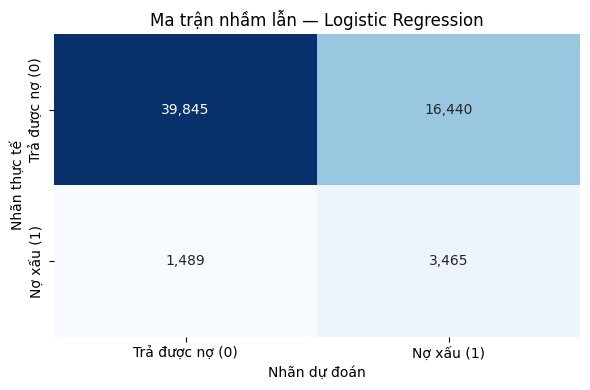

In [24]:
# Chuyển sang chế độ hiển thị biểu đồ ngay trong notebook.
get_ipython().run_line_magic("matplotlib", "inline")

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    ma_tran_lr,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    ax=ax,
)
ax.set_xlabel("Nhãn dự đoán")
ax.set_ylabel("Nhãn thực tế")
ax.set_title("Ma trận nhầm lẫn — Logistic Regression")
fig.tight_layout()
plt.show()

#### b. Các chỉ số đánh giá

- **Precision:** trong số khách bị dự đoán là nợ xấu, có bao nhiêu người thực sự nợ xấu.
- **Recall:** trong số khách thực sự nợ xấu, mô hình phát hiện được bao nhiêu người.
- **F1-score:** điểm cân bằng giữa Precision và Recall.
- **ROC-AUC:** khả năng xếp khách nợ xấu có mức rủi ro cao hơn khách trả được nợ.
- **PR-AUC:** khả năng tìm đúng nhóm nợ xấu khi dữ liệu mất cân bằng; nên đọc cùng tỷ lệ nợ xấu ban đầu.

Đoạn code bên dưới tính các chỉ số dùng để đánh giá và so sánh các mô hình.

In [25]:
chi_so_lr_test = {
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_lr),
    "PR-AUC": average_precision_score(y_test, y_test_proba_lr),
    "F1-Score": f1_score(y_test, y_test_pred_lr),
    "Precision": precision_score(y_test, y_test_pred_lr),
    "Recall": recall_score(y_test, y_test_pred_lr),
}

display(pd.DataFrame([chi_so_lr_test], index=["Logistic Regression"]).round(4))
print(f"Tỷ lệ nợ xấu thực tế ở Test: {y_test.mean():.4f}")

,ROC-AUC,PR-AUC,F1-Score,Precision,Recall
Logistic Regression,0.7714,0.2544,0.2788,0.1741,0.6994


Tỷ lệ nợ xấu thực tế ở Test: 0.0809


**Nhận xét:**

- Logistic Regression phát hiện đúng **3.465/4.954 khách nợ xấu**, tương ứng Recall `0,6994`, nhưng tạo 16.440 cảnh báo nhầm nên Precision chỉ đạt `0,1741`.
- F1-score `0,2788` và PR-AUC `0,2544` cho thấy mô hình phù hợp làm baseline, nhưng khả năng cân bằng giữa phát hiện nợ xấu và cảnh báo nhầm còn hạn chế.


### 6. Giải thích mô hình bằng hệ số

Logistic Regression gán một hệ số cho mỗi feature:

- **Hệ số dương:** feature làm dự đoán rủi ro nợ xấu tăng.
- **Hệ số âm:** feature làm dự đoán rủi ro nợ xấu giảm.
- **Hệ số gần 0:** feature có tác động tuyến tính nhỏ.
- **Giá trị tuyệt đối càng lớn:** feature tác động càng mạnh đến dự đoán.

Các feature số đã được chuẩn hóa nên có thể so sánh độ lớn hệ số thuận tiện hơn. Tuy nhiên, hệ số chỉ phản ánh mối liên hệ mô hình học được, không chứng minh quan hệ nguyên nhân–kết quả. Các nhóm one-hot có ít khách cũng cần được diễn giải thận trọng.

Đoạn code bên dưới lấy 10 hệ số âm nhất và 10 hệ số dương nhất để xem các feature nổi bật.

In [26]:
# Ghép hệ số với đúng tên feature.
he_so = pd.Series(lr_model.coef_[0], index=FEATURE_NAMES).sort_values()


def dem_khach_trong_nhom(ten_cot):
    """Đếm số khách Train thuộc một nhóm one-hot."""
    if ten_cot in encoded_cols:
        return f"{int((X_train_prep[ten_cot] == 1).sum()):,}"
    return "(cột số)"


# Chọn 10 feature giảm và 10 feature tăng rủi ro mạnh nhất.
cac_cot_noi_bat = list(he_so.head(10).index) + list(he_so.tail(10).index)
bang_he_so = pd.DataFrame({
    "Feature": cac_cot_noi_bat,
    "Hệ số": [round(float(he_so[cot]), 4) for cot in cac_cot_noi_bat],
    "Chiều tác động": [
        "Giảm rủi ro" if he_so[cot] < 0 else "Tăng rủi ro"
        for cot in cac_cot_noi_bat
    ],
    "Số khách thuộc nhóm (Train)": [
        dem_khach_trong_nhom(cot) for cot in cac_cot_noi_bat
    ],
})

display(bang_he_so)

so_cot_gan_0 = int((he_so.abs() < 0.01).sum())
print(f"Số feature có hệ số gần 0: {so_cot_gan_0:,} / {len(he_so):,}")

,Feature,Hệ số,Chiều tác động,Số khách thuộc nhóm (Train)
0,name_education_type_Academic degree,-0.6065,Giảm rủi ro,140
1,organization_type_Industry: type 12,-0.4867,Giảm rủi ro,287
2,organization_type_Transport: type 1,-0.4359,Giảm rủi ro,158
3,age_income_interaction_55+ | Rất cao,-0.3956,Giảm rủi ro,"5,953"
4,organization_type_Military,-0.3750,Giảm rủi ro,"2,120"
5,age_income_interaction_55+ | Rất thấp,-0.3693,Giảm rủi ro,"16,544"
6,name_type_suite_Missing,-0.3509,Giảm rủi ro,835
7,age_income_interaction_<25 | Rất cao,-0.3485,Giảm rủi ro,699
8,amt_goods_price,-0.3452,Giảm rủi ro,(cột số)
9,organization_type_Trade: type 6,-0.3141,Giảm rủi ro,487


Số feature có hệ số gần 0: 41 / 397


Đoạn code bên dưới trực quan hóa hệ số: màu xanh làm dự đoán rủi ro giảm, màu đỏ làm dự đoán rủi ro tăng.

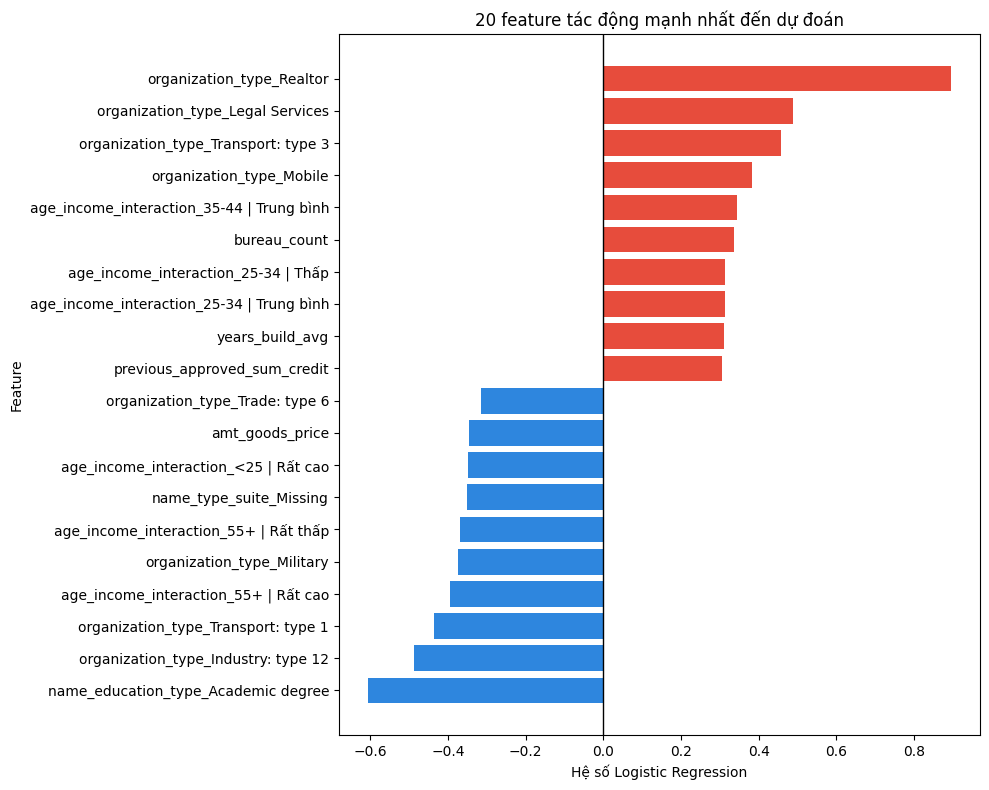

In [27]:
# Chuyển sang chế độ hiển thị biểu đồ ngay trong notebook.
get_ipython().run_line_magic("matplotlib", "inline")

he_so_noi_bat = he_so.loc[cac_cot_noi_bat]
mau_he_so = ["#2E86DE" if gia_tri < 0 else "#E74C3C" for gia_tri in he_so_noi_bat]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(he_so_noi_bat.index, he_so_noi_bat.values, color=mau_he_so)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Hệ số Logistic Regression")
ax.set_ylabel("Feature")
ax.set_title("20 feature tác động mạnh nhất đến dự đoán")
fig.tight_layout()
plt.show()

**Nhận xét:**

- Các hệ số cho thấy mô hình tuyến tính sử dụng cả đặc điểm nhân khẩu học, tổ chức làm việc, quy mô khoản vay và lịch sử tín dụng.
- Một số nhóm chỉ có ít quan sát trong Train, vì vậy hệ số lớn cần được diễn giải thận trọng.
- Hệ số chỉ thể hiện chiều tác động trong Logistic Regression sau tiền xử lý, không chứng minh feature là nguyên nhân làm phát sinh nợ xấu.


### 7. Lưu mô hình Logistic Regression

Đoạn code bên dưới lưu Logistic Regression như một mô hình ứng viên để so sánh và lựa chọn ở phần sau.

In [28]:
# Lưu thông tin và metric của mô hình ứng viên.
metrics_lr = {
    "model_name": "Credit Risk Classification - Logistic Regression",
    "model_type": type(lr_model).__name__,
    "model_version": "1.0.0",
    "status": "Candidate",
    "dataset": "application_features",
    "target": TARGET_COLUMN,
    "trained_date": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "trained_from": "06_modeling_evaluation.ipynb",
    "train_rows": len(X_train_lr),
    "test_rows": len(X_test_lr),
    "train_test_split": "80/20 Stratified",
    "features_count": len(FEATURE_NAMES),
    "decision_threshold": NGUONG_TAM_THOI_LR,
    "accuracy": round(float((y_test_pred_lr == y_test.to_numpy()).mean()), 4),
    "roc_auc": round(float(chi_so_lr_test["ROC-AUC"]), 4),
    "pr_auc": round(float(chi_so_lr_test["PR-AUC"]), 4),
    "precision_class_1": round(float(chi_so_lr_test["Precision"]), 4),
    "recall_class_1": round(float(chi_so_lr_test["Recall"]), 4),
    "f1_class_1": round(float(chi_so_lr_test["F1-Score"]), 4),
    "precision_macro": round(float(precision_score(y_test, y_test_pred_lr, average="macro")), 4),
    "recall_macro": round(float(recall_score(y_test, y_test_pred_lr, average="macro")), 4),
    "f1_macro": round(float(f1_score(y_test, y_test_pred_lr, average="macro")), 4),
    "f1_weighted": round(float(f1_score(y_test, y_test_pred_lr, average="weighted")), 4),
    "confusion_matrix": confusion_matrix(y_test, y_test_pred_lr).tolist(),
    "author": "Nhóm 01",
}

# Gói mô hình kèm thông tin cần thiết để sử dụng lại.
goi_logistic = {
    "model": lr_model,
    "feature_names": FEATURE_NAMES,
    "can_chuan_hoa": True,
    "nguong_tam_thoi": NGUONG_TAM_THOI_LR,
    "metrics_test": metrics_lr,
}

duong_dan_lr = MODELS_DIR / "logistic_regression.pkl"
duong_dan_metrics_lr = MODELS_DIR / "logistic_regression_metrics.json"

joblib.dump(goi_logistic, duong_dan_lr)
duong_dan_metrics_lr.write_text(
    json.dumps(metrics_lr, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"Đã lưu mô hình: {duong_dan_lr}")
print(f"Đã lưu metric: {duong_dan_metrics_lr}")
display(pd.DataFrame([{
    "ROC-AUC": metrics_lr["roc_auc"],
    "PR-AUC": metrics_lr["pr_auc"],
    "Precision": metrics_lr["precision_class_1"],
    "Recall": metrics_lr["recall_class_1"],
    "F1-Score": metrics_lr["f1_class_1"],
}], index=["Logistic Regression"]))

Đã lưu mô hình: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\logistic_regression.pkl
Đã lưu metric: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\logistic_regression_metrics.json


,ROC-AUC,PR-AUC,Precision,Recall,F1-Score
Logistic Regression,0.7714,0.2544,0.1741,0.6994,0.2788


## V. Mô hình Random Forest

### 1. Giới thiệu Random Forest

Random Forest là mô hình kết hợp nhiều cây quyết định. Mỗi cây học từ một phần dữ liệu và đưa ra dự đoán riêng; kết quả cuối cùng được tổng hợp từ tất cả các cây.

Có thể hình dung 300 nhân viên tín dụng cùng đánh giá một hồ sơ. Mỗi người xem một số thông tin khác nhau, sau đó tổng hợp ý kiến để xác định rủi ro.

Khác với Logistic Regression, Random Forest có thể học các quan hệ phi tuyến và tương tác phức tạp giữa các feature. Mô hình cũng cung cấp Feature Importance để xem những feature được sử dụng nhiều trong quá trình dự đoán.

### 2. Lựa chọn feature đầu vào

Đoạn code bên dưới sử dụng toàn bộ feature đã xử lý ở Mục III. Random Forest không bắt buộc chuẩn hóa dữ liệu.

In [29]:
# Random Forest dùng dữ liệu đã xử lý nhưng chưa chuẩn hóa.
X_train_rf = X_train_prep
X_test_rf = X_test_prep

# Kiểm tra Train và Test có cùng feature và không còn giá trị thiếu.
assert list(X_train_rf.columns) == FEATURE_NAMES
assert list(X_test_rf.columns) == FEATURE_NAMES
assert not X_train_rf.isna().any().any()
assert not X_test_rf.isna().any().any()

bang_du_lieu_rf = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Test"],
    "Số dòng": [len(X_train_rf), len(X_test_rf)],
    "Số feature": [X_train_rf.shape[1], X_test_rf.shape[1]],
    "Số ô thiếu": [
        int(X_train_rf.isna().sum().sum()),
        int(X_test_rf.isna().sum().sum()),
    ],
})

display(bang_du_lieu_rf)

,Tập dữ liệu,Số dòng,Số feature,Số ô thiếu
0,Train,244956,397,0
1,Test,61239,397,0


### 3. Huấn luyện mô hình

Các tham số chính:

- `n_estimators=300`: xây dựng 300 cây quyết định.
- `max_depth=12`: giới hạn độ sâu để cây không quá phức tạp.
- `min_samples_leaf=50`: mỗi nút lá phải có ít nhất 50 khách hàng.
- `class_weight="balanced"`: tăng trọng số cho nhóm nợ xấu đang chiếm tỷ lệ thấp.

Đoạn code bên dưới khởi tạo và huấn luyện Random Forest trên tập Train.

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=300,         # Số cây trong rừng.
    max_depth=12,             # Độ sâu tối đa của mỗi cây.
    min_samples_leaf=50,      # Số khách tối thiểu tại một nút lá.
    class_weight="balanced", # Cân bằng trọng số hai lớp.
    n_jobs=-1,                # Sử dụng các nhân CPU để huấn luyện nhanh hơn.
    random_state=42,          # Giúp kết quả có thể lặp lại.
)

# Đo thời gian huấn luyện.
bat_dau = time.time()
rf_model.fit(X_train_rf, y_train)
thoi_gian_rf = time.time() - bat_dau

print(f"Thời gian huấn luyện: {thoi_gian_rf:.1f} giây")
print(f"Số cây đã huấn luyện: {len(rf_model.estimators_):,}")

Thời gian huấn luyện: 79.5 giây
Số cây đã huấn luyện: 300


### 4. Dự đoán trên tập Test

Đoạn code bên dưới tính xác suất nợ xấu và tạo nhãn dự đoán tại ngưỡng tạm thời 0,5.

In [31]:
# Lấy xác suất của lớp nợ xấu (target=1).
y_test_proba_rf = rf_model.predict_proba(X_test_rf)[:, 1]

# Chuyển xác suất thành nhãn dự đoán.
NGUONG_TAM_THOI_RF = 0.5
y_test_pred_rf = (y_test_proba_rf >= NGUONG_TAM_THOI_RF).astype(int)

# Hiển thị 10 dự đoán đầu tiên để minh họa.
du_doan_mau_rf = pd.DataFrame({
    "Nhãn thực tế": y_test.iloc[:10].to_numpy(),
    "Xác suất nợ xấu": y_test_proba_rf[:10],
    "Nhãn dự đoán": y_test_pred_rf[:10],
}, index=y_test.index[:10])

display(du_doan_mau_rf.round(4))

,Nhãn thực tế,Xác suất nợ xấu,Nhãn dự đoán
3058,0,0.3224,0
273919,1,0.6010,1
286776,0,0.4357,0
50673,0,0.4369,0
144087,0,0.3047,0
30119,0,0.5949,1
200377,0,0.4996,0
195797,0,0.2442,0
39664,0,0.2394,0
168953,0,0.2252,0


### 5. Đánh giá mô hình

#### a. Ma trận nhầm lẫn

Đoạn code bên dưới đếm số dự đoán đúng, số cảnh báo nhầm và số khách nợ xấu bị bỏ sót.

In [32]:
# Tính ma trận nhầm lẫn.
ma_tran_rf = confusion_matrix(y_test, y_test_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = ma_tran_rf.ravel()

bang_ma_tran_rf = pd.DataFrame(
    ma_tran_rf,
    index=["Thực tế: Trả được nợ", "Thực tế: Nợ xấu"],
    columns=["Dự đoán: Trả được nợ", "Dự đoán: Nợ xấu"],
)

display(bang_ma_tran_rf)
print(f"Phát hiện đúng nợ xấu: {tp_rf:,}")
print(f"Bỏ sót nợ xấu: {fn_rf:,}")
print(f"Cảnh báo nhầm: {fp_rf:,}")

,Dự đoán: Trả được nợ,Dự đoán: Nợ xấu
Thực tế: Trả được nợ,43186,13099
Thực tế: Nợ xấu,1901,3053


Phát hiện đúng nợ xấu: 3,053
Bỏ sót nợ xấu: 1,901
Cảnh báo nhầm: 13,099


Đoạn code bên dưới vẽ ma trận nhầm lẫn của Random Forest.

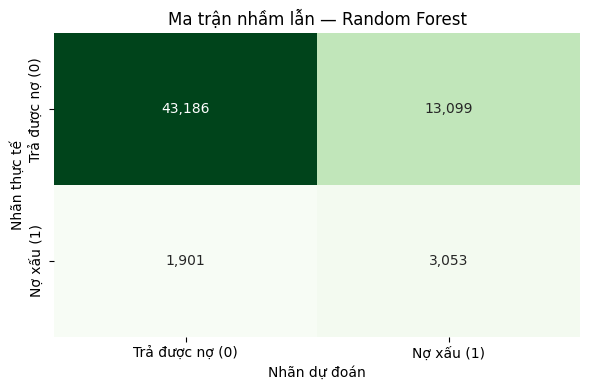

In [33]:
# Hiển thị biểu đồ ngay trong notebook.
get_ipython().run_line_magic("matplotlib", "inline")

plt.figure(figsize=(6, 4))
sns.heatmap(
    ma_tran_rf,
    annot=True,
    fmt=",d",
    cmap="Greens",
    cbar=False,
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
)
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")
plt.title("Ma trận nhầm lẫn — Random Forest")
plt.tight_layout()
plt.show()

#### b. Các chỉ số đánh giá

Đoạn code bên dưới tính trực tiếp các metric của Random Forest trên tập Test.

In [34]:
# Tính metric cho lớp nợ xấu (target=1).
chi_so_rf_test = {
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_rf),
    "PR-AUC": average_precision_score(y_test, y_test_proba_rf),
    "F1-Score": f1_score(y_test, y_test_pred_rf),
    "Precision": precision_score(y_test, y_test_pred_rf),
    "Recall": recall_score(y_test, y_test_pred_rf),
}

display(pd.DataFrame([chi_so_rf_test], index=["Random Forest"]).round(4))
print(f"Tỷ lệ nợ xấu thực tế ở Test: {y_test.mean():.4f}")

,ROC-AUC,PR-AUC,F1-Score,Precision,Recall
Random Forest,0.76,0.2424,0.2893,0.189,0.6163


Tỷ lệ nợ xấu thực tế ở Test: 0.0809


**Nhận xét:**

- Random Forest có Precision `0,1890` và F1-score `0,2893`, cao hơn Logistic Regression, đồng thời giảm cảnh báo nhầm xuống 13.099.
- Đổi lại, Recall giảm còn `0,6163`, nghĩa là mô hình bỏ sót 1.901 khách nợ xấu. PR-AUC `0,2424` cũng thấp nhất trong ba mô hình.


### 6. Phân tích Feature Importance

Feature Importance cho biết feature nào được Random Forest sử dụng nhiều trong quá trình dự đoán. Giá trị càng lớn thì feature càng quan trọng đối với mô hình.

Feature Importance không cho biết feature làm rủi ro tăng hay giảm và cũng không chứng minh quan hệ nguyên nhân–kết quả.

Đoạn code bên dưới hiển thị 20 feature quan trọng nhất của Random Forest.

In [35]:
# Ghép tên feature với điểm quan trọng.
do_quan_trong_rf = pd.Series(
    rf_model.feature_importances_,
    index=FEATURE_NAMES,
).sort_values(ascending=False)

# Lấy 20 feature có điểm cao nhất.
top_20_rf = do_quan_trong_rf.head(20)
bang_quan_trong_rf = top_20_rf.rename("Feature Importance").reset_index()
bang_quan_trong_rf.columns = ["Feature", "Feature Importance"]

display(bang_quan_trong_rf.round(4))

,Feature,Feature Importance
0,ext_ltv_interaction,0.0947
1,ext_sources_mean,0.0899
2,ext_min_ltv_interaction,0.0702
3,ext_sources_min,0.0553
4,ext_source_2,0.0417
5,ext_source_3,0.0347
6,ext_bureau_debt_interaction,0.0211
7,ext_dti_interaction,0.0198
8,ext_sources_std,0.0184
9,ext_source_1,0.0160


Đoạn code bên dưới vẽ biểu đồ 20 feature quan trọng nhất.

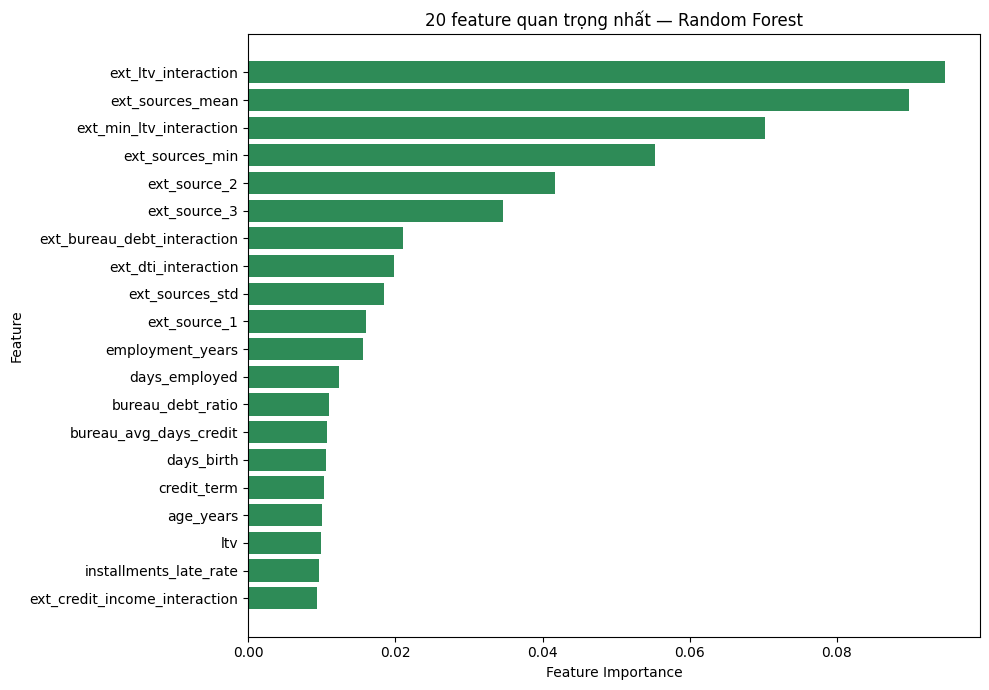

In [36]:
# Hiển thị biểu đồ ngay trong notebook.
get_ipython().run_line_magic("matplotlib", "inline")

plt.figure(figsize=(10, 7))
plt.barh(top_20_rf.index[::-1], top_20_rf.values[::-1], color="#2E8B57")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("20 feature quan trọng nhất — Random Forest")
plt.tight_layout()
plt.show()

**Nhận xét:**

- Random Forest ưu tiên nhóm điểm đánh giá ngoài và các interaction liên quan; `ext_ltv_interaction` đứng đầu với importance `0,0947`.
- Cả bốn interaction vòng 3 đều xuất hiện trong top 20 của Random Forest, nhưng Feature Importance chỉ cho biết mức độ mô hình sử dụng feature, không chứng minh chúng cải thiện metric tổng thể.


### 7. Lưu mô hình Random Forest

Đoạn code bên dưới lưu Random Forest và các metric để sử dụng ở phần so sánh, lựa chọn mô hình.

In [37]:
# Lưu thông tin và metric của mô hình ứng viên.
metrics_rf = {
    "model_name": "Credit Risk Classification - Random Forest",
    "model_type": type(rf_model).__name__,
    "model_version": "1.0.0",
    "status": "Candidate",
    "dataset": "application_features",
    "target": TARGET_COLUMN,
    "trained_date": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "trained_from": "06_modeling_evaluation.ipynb",
    "train_rows": len(X_train_rf),
    "test_rows": len(X_test_rf),
    "train_test_split": "80/20 Stratified",
    "features_count": len(FEATURE_NAMES),
    "decision_threshold": NGUONG_TAM_THOI_RF,
    "accuracy": round(float((y_test_pred_rf == y_test.to_numpy()).mean()), 4),
    "roc_auc": round(float(chi_so_rf_test["ROC-AUC"]), 4),
    "pr_auc": round(float(chi_so_rf_test["PR-AUC"]), 4),
    "precision_class_1": round(float(chi_so_rf_test["Precision"]), 4),
    "recall_class_1": round(float(chi_so_rf_test["Recall"]), 4),
    "f1_class_1": round(float(chi_so_rf_test["F1-Score"]), 4),
    "confusion_matrix": ma_tran_rf.tolist(),
    "author": "Nhóm 01",
}

# Gói mô hình kèm các thông tin cần dùng lại.
goi_random_forest = {
    "model": rf_model,
    "feature_names": FEATURE_NAMES,
    "can_chuan_hoa": False,
    "nguong_tam_thoi": NGUONG_TAM_THOI_RF,
    "metrics_test": metrics_rf,
}

duong_dan_rf = MODELS_DIR / "random_forest.pkl"
duong_dan_metrics_rf = MODELS_DIR / "random_forest_metrics.json"

# Ghi mô hình và metric xuống thư mục models.
joblib.dump(goi_random_forest, duong_dan_rf)
duong_dan_metrics_rf.write_text(
    json.dumps(metrics_rf, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"Đã lưu mô hình: {duong_dan_rf}")
print(f"Đã lưu metric: {duong_dan_metrics_rf}")

Đã lưu mô hình: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\random_forest.pkl
Đã lưu metric: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\random_forest_metrics.json


## VI. Mô hình HistGradientBoosting

### 1. Giới thiệu HistGradientBoosting

HistGradientBoosting xây dựng nhiều cây quyết định theo thứ tự. Mỗi cây mới tập trung sửa những lỗi mà các cây trước còn dự đoán sai.

Có thể hình dung một nhóm nhân viên tín dụng đánh giá lần lượt. Người sau xem lại các hồ sơ mà những người trước xử lý chưa tốt và điều chỉnh kết quả từng bước.

Khác với Random Forest xây dựng nhiều cây tương đối độc lập, HistGradientBoosting cho các cây học nối tiếp nhau. Mô hình còn chia giá trị số thành các khoảng (`histogram`) để huấn luyện nhanh hơn trên dữ liệu lớn.

### 2. Lựa chọn feature đầu vào

Đoạn code bên dưới sử dụng toàn bộ feature đã xử lý ở Mục III. HistGradientBoosting không bắt buộc chuẩn hóa dữ liệu.

In [38]:
# HistGradientBoosting dùng dữ liệu đã xử lý nhưng chưa chuẩn hóa.
X_train_hgb = X_train_prep
X_test_hgb = X_test_prep

# Kiểm tra Train và Test có cùng feature và không còn giá trị thiếu.
assert list(X_train_hgb.columns) == FEATURE_NAMES
assert list(X_test_hgb.columns) == FEATURE_NAMES
assert not X_train_hgb.isna().any().any()
assert not X_test_hgb.isna().any().any()

bang_du_lieu_hgb = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Test"],
    "Số dòng": [len(X_train_hgb), len(X_test_hgb)],
    "Số feature": [X_train_hgb.shape[1], X_test_hgb.shape[1]],
    "Số ô thiếu": [
        int(X_train_hgb.isna().sum().sum()),
        int(X_test_hgb.isna().sum().sum()),
    ],
})

display(bang_du_lieu_hgb)

,Tập dữ liệu,Số dòng,Số feature,Số ô thiếu
0,Train,244956,397,0
1,Test,61239,397,0


### 3. Huấn luyện mô hình

Các tham số chính:

- `max_iter=200`: mô hình được phép học tối đa 200 vòng.
- `learning_rate=0.1`: mỗi vòng điều chỉnh kết quả một lượng nhỏ.
- `max_leaf_nodes=31`: giới hạn số nút lá của mỗi cây.
- `min_samples_leaf=50`: mỗi nút lá phải có ít nhất 50 khách hàng.
- `class_weight="balanced"`: tăng trọng số cho nhóm nợ xấu đang chiếm tỷ lệ thấp.

Đoạn code bên dưới khởi tạo và huấn luyện HistGradientBoosting trên tập Train.

In [39]:
hgb_model = HistGradientBoostingClassifier(
    max_iter=200,             # Số vòng học tối đa.
    learning_rate=0.1,        # Mức điều chỉnh sau mỗi vòng.
    max_leaf_nodes=31,        # Số nút lá tối đa của mỗi cây.
    min_samples_leaf=50,      # Số khách tối thiểu tại một nút lá.
    class_weight="balanced", # Cân bằng trọng số hai lớp.
    random_state=42,          # Giúp kết quả có thể lặp lại.
)

# Đo thời gian huấn luyện.
bat_dau = time.time()
hgb_model.fit(X_train_hgb, y_train)
thoi_gian_hgb = time.time() - bat_dau

print(f"Thời gian huấn luyện: {thoi_gian_hgb:.1f} giây")
print(f"Số vòng đã thực hiện: {hgb_model.n_iter_:,}")

Thời gian huấn luyện: 24.1 giây
Số vòng đã thực hiện: 113


### 4. Dự đoán trên tập Test

Đoạn code bên dưới tính xác suất nợ xấu và tạo nhãn dự đoán tại ngưỡng tạm thời 0,5.

In [40]:
# Lấy xác suất của lớp nợ xấu (target=1).
y_test_proba_hgb = hgb_model.predict_proba(X_test_hgb)[:, 1]

# Chuyển xác suất thành nhãn dự đoán.
NGUONG_TAM_THOI_HGB = 0.5
y_test_pred_hgb = (y_test_proba_hgb >= NGUONG_TAM_THOI_HGB).astype(int)

# Hiển thị 10 dự đoán đầu tiên để minh họa.
du_doan_mau_hgb = pd.DataFrame({
    "Nhãn thực tế": y_test.iloc[:10].to_numpy(),
    "Xác suất nợ xấu": y_test_proba_hgb[:10],
    "Nhãn dự đoán": y_test_pred_hgb[:10],
}, index=y_test.index[:10])

display(du_doan_mau_hgb.round(4))

,Nhãn thực tế,Xác suất nợ xấu,Nhãn dự đoán
3058,0,0.3916,0
273919,1,0.5904,1
286776,0,0.2082,0
50673,0,0.1314,0
144087,0,0.3145,0
30119,0,0.6811,1
200377,0,0.5629,1
195797,0,0.2167,0
39664,0,0.2078,0
168953,0,0.1625,0


### 5. Đánh giá mô hình

#### a. Ma trận nhầm lẫn

Đoạn code bên dưới đếm số dự đoán đúng, số cảnh báo nhầm và số khách nợ xấu bị bỏ sót.

In [41]:
# Tính ma trận nhầm lẫn.
ma_tran_hgb = confusion_matrix(y_test, y_test_pred_hgb)
tn_hgb, fp_hgb, fn_hgb, tp_hgb = ma_tran_hgb.ravel()

bang_ma_tran_hgb = pd.DataFrame(
    ma_tran_hgb,
    index=["Thực tế: Trả được nợ", "Thực tế: Nợ xấu"],
    columns=["Dự đoán: Trả được nợ", "Dự đoán: Nợ xấu"],
)

display(bang_ma_tran_hgb)
print(f"Phát hiện đúng nợ xấu: {tp_hgb:,}")
print(f"Bỏ sót nợ xấu: {fn_hgb:,}")
print(f"Cảnh báo nhầm: {fp_hgb:,}")

,Dự đoán: Trả được nợ,Dự đoán: Nợ xấu
Thực tế: Trả được nợ,41188,15097
Thực tế: Nợ xấu,1550,3404


Phát hiện đúng nợ xấu: 3,404
Bỏ sót nợ xấu: 1,550
Cảnh báo nhầm: 15,097


Đoạn code bên dưới vẽ ma trận nhầm lẫn của HistGradientBoosting.

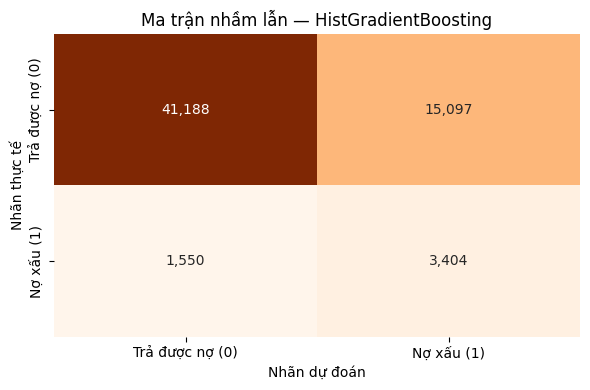

In [42]:
# Hiển thị biểu đồ ngay trong notebook.
get_ipython().run_line_magic("matplotlib", "inline")

plt.figure(figsize=(6, 4))
sns.heatmap(
    ma_tran_hgb,
    annot=True,
    fmt=",d",
    cmap="Oranges",
    cbar=False,
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
)
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")
plt.title("Ma trận nhầm lẫn — HistGradientBoosting")
plt.tight_layout()
plt.show()

#### b. Các chỉ số đánh giá

Đoạn code bên dưới tính trực tiếp các metric của HistGradientBoosting trên tập Test.

In [43]:
# Tính metric cho lớp nợ xấu (target=1).
chi_so_hgb_test = {
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_hgb),
    "PR-AUC": average_precision_score(y_test, y_test_proba_hgb),
    "F1-Score": f1_score(y_test, y_test_pred_hgb),
    "Precision": precision_score(y_test, y_test_pred_hgb),
    "Recall": recall_score(y_test, y_test_pred_hgb),
}

display(pd.DataFrame([chi_so_hgb_test], index=["HistGradientBoosting"]).round(4))
print(f"Tỷ lệ nợ xấu thực tế ở Test: {y_test.mean():.4f}")

,ROC-AUC,PR-AUC,F1-Score,Precision,Recall
HistGradientBoosting,0.778,0.2717,0.2903,0.184,0.6871


Tỷ lệ nợ xấu thực tế ở Test: 0.0809


**Nhận xét:**

- HistGradientBoosting đạt ROC-AUC `0,7780`, PR-AUC `0,2717` và F1-score `0,2903`, đều cao nhất trong ba mô hình.
- Mô hình phát hiện đúng 3.404 khách nợ xấu, đạt Recall `0,6871`; Precision `0,1840` vẫn thấp do target mất cân bằng và đang sử dụng ngưỡng tạm thời `0,5`.
- Đây là mô hình phù hợp nhất để tiếp tục xem xét, nhưng ngưỡng dự đoán cần được lựa chọn trên Validation thay vì tối ưu trực tiếp trên Test.


### 6. Phân tích Permutation Importance

HistGradientBoosting không cung cấp trực tiếp `feature_importances_` như Random Forest. Vì vậy, phần này sử dụng Permutation Importance:

1. Đảo ngẫu nhiên giá trị của một feature.
2. Dùng mô hình dự đoán lại.
3. Đo mức PR-AUC bị giảm.

PR-AUC giảm càng nhiều thì feature đó càng quan trọng. Kết quả không cho biết chiều tăng hoặc giảm rủi ro và không chứng minh quan hệ nguyên nhân–kết quả.

#### a. Xác định 20 feature quan trọng nhất

Đoạn code bên dưới lấy cố định 10.000 dòng Test để thời gian tính Permutation Importance hợp lý hơn.

In [44]:
# Lấy tối đa 10.000 dòng Test bằng random_state cố định.
so_mau_importance = min(10_000, len(X_test_hgb))
X_importance_hgb = X_test_hgb.sample(
    n=so_mau_importance,
    random_state=42,
)

# Lấy target tương ứng với đúng các dòng đã chọn.
y_importance_hgb = y_test.loc[X_importance_hgb.index]

print(f"Số dòng dùng tính Permutation Importance: {len(X_importance_hgb):,}")
print(f"Tỷ lệ nợ xấu trong mẫu: {y_importance_hgb.mean():.4f}")

Số dòng dùng tính Permutation Importance: 10,000
Tỷ lệ nợ xấu trong mẫu: 0.0794


Đoạn code bên dưới đảo từng feature 3 lần và đo mức PR-AUC bị giảm.

In [45]:
# Đo thời gian tính Permutation Importance.
bat_dau = time.time()
ket_qua_importance_hgb = permutation_importance(
    hgb_model,
    X_importance_hgb,
    y_importance_hgb,
    scoring="average_precision", # Dùng PR-AUC cho dữ liệu mất cân bằng.
    n_repeats=3,                 # Đảo mỗi feature 3 lần rồi lấy trung bình.
    random_state=42,             # Giúp kết quả có thể lặp lại.
    n_jobs=-1,                   # Sử dụng các nhân CPU để chạy nhanh hơn.
)
thoi_gian_importance_hgb = time.time() - bat_dau

# Ghép tên feature với mức PR-AUC bị giảm.
do_quan_trong_hgb = pd.Series(
    ket_qua_importance_hgb.importances_mean,
    index=FEATURE_NAMES,
).sort_values(ascending=False)

# Lấy 20 feature quan trọng nhất.
top_20_hgb = do_quan_trong_hgb.head(20)
bang_quan_trong_hgb = top_20_hgb.rename("Độ giảm PR-AUC").reset_index()
bang_quan_trong_hgb.columns = ["Feature", "Độ giảm PR-AUC"]

display(bang_quan_trong_hgb.round(4))
print(f"Thời gian tính Permutation Importance: {thoi_gian_importance_hgb:.1f} giây")

,Feature,Độ giảm PR-AUC
0,ext_ltv_interaction,0.0420
1,ext_sources_mean,0.0184
2,credit_term,0.0139
3,ext_source_1,0.0114
4,credit_card_recent_12m_max_utilization,0.0083
5,installments_sum_paid,0.0065
6,code_gender_F,0.0065
7,pos_cash_history_months,0.0050
8,bureau_sum_credit,0.0043
9,flag_own_car_N,0.0036


Thời gian tính Permutation Importance: 33.4 giây


**Nhận xét:**

- `ext_ltv_interaction` đứng đầu: khi đảo feature này, PR-AUC giảm `0,0420`. Tiếp theo là `ext_sources_mean`, `credit_term` và `ext_source_1`.
- Nhóm điểm đánh giá ngoài, áp lực khoản vay và lịch sử tín dụng là ba nguồn tín hiệu chính của HistGradientBoosting.
- Permutation Importance được tính trên cùng mẫu Test cố định nên phù hợp để so sánh đóng góp tương đối giữa các feature trong mô hình cuối.


#### b. Kiểm tra độ quan trọng của 8 feature vòng 1

Đoạn code bên dưới hiển thị độ quan trọng và thứ hạng của 8 feature đã bổ sung ở vòng 1.


In [46]:
# Danh sách 8 feature vòng 1 từ NB02.
feature_vong_1 = [
    "installments_underpaid_count",
    "installments_underpaid_amount",
    "installments_recent_12m_late_count",
    "credit_card_contract_count",
    "credit_card_avg_utilization",
    "credit_card_max_utilization",
    "pos_cash_contract_count",
    "pos_cash_recent_12m_dpd_count",
]

# Tạo bảng thứ hạng của toàn bộ feature.
xep_hang_hgb = do_quan_trong_hgb.reset_index()
xep_hang_hgb.columns = ["Feature", "Độ giảm PR-AUC"]
xep_hang_hgb["Xếp hạng"] = range(1, len(xep_hang_hgb) + 1)

# Chỉ lấy 8 feature vòng 1 và sắp xếp từ quan trọng nhất.
bang_quan_trong_vong_1 = xep_hang_hgb[
    xep_hang_hgb["Feature"].isin(feature_vong_1)
].copy()
assert len(bang_quan_trong_vong_1) == len(feature_vong_1), (
    "Có feature vòng 1 không tồn tại trong kết quả Permutation Importance."
)
bang_quan_trong_vong_1["Trong top 20"] = np.where(
    bang_quan_trong_vong_1["Xếp hạng"] <= 20, "Có", "Không"
)

display(bang_quan_trong_vong_1.round({"Độ giảm PR-AUC": 4}))


,Feature,Độ giảm PR-AUC,Xếp hạng,Trong top 20
47,credit_card_avg_utilization,0.0006,48,Không
55,installments_underpaid_amount,0.0005,56,Không
71,installments_underpaid_count,0.0003,72,Không
138,pos_cash_contract_count,0.0000,139,Không
143,credit_card_contract_count,0.0000,144,Không
329,pos_cash_recent_12m_dpd_count,-0.0001,330,Không
357,credit_card_max_utilization,-0.0002,358,Không
359,installments_recent_12m_late_count,-0.0002,360,Không


**Nhận xét:**

- Trong mô hình cuối, cả 8 feature vòng 1 đều nằm ngoài top 20; feature cao nhất là `credit_card_avg_utilization` ở hạng 48.
- Ở thí nghiệm vòng 1 trước đó, một số feature từng có thứ hạng tốt hơn. Việc giảm hạng sau khi thêm vòng 2–3 cho thấy các feature mới có thể chia sẻ hoặc thay thế tín hiệu của feature cũ, không phải hai kết quả mâu thuẫn.


#### c. Kiểm tra độ quan trọng của 10 feature vòng 2

Đoạn code bên dưới hiển thị độ quan trọng và thứ hạng của 8 summary feature mới cùng 2 tỷ lệ được tạo tại NB05.


In [47]:
# Tám summary feature mới từ NB02 và hai tỷ lệ mới từ NB05.
feature_vong_2 = [
    "bureau_recent_12m_overdue_count",
    "previous_recent_12m_approved_count",
    "previous_recent_12m_refused_count",
    "installments_recent_12m_count",
    "installments_recent_12m_underpaid_count",
    "installments_recent_12m_underpaid_amount",
    "credit_card_recent_12m_max_utilization",
    "pos_cash_recent_12m_max_dpd",
    "installments_recent_12m_late_rate",
    "installments_recent_12m_underpaid_rate",
]

# Lấy thứ hạng của 10 feature vòng 2.
bang_quan_trong_vong_2 = xep_hang_hgb[
    xep_hang_hgb["Feature"].isin(feature_vong_2)
].copy()
assert len(bang_quan_trong_vong_2) == len(feature_vong_2), (
    "Có feature vòng 2 không tồn tại trong kết quả Permutation Importance."
)
bang_quan_trong_vong_2["Trong top 20"] = np.where(
    bang_quan_trong_vong_2["Xếp hạng"] <= 20, "Có", "Không"
)

display(bang_quan_trong_vong_2.round({"Độ giảm PR-AUC": 4}))


,Feature,Độ giảm PR-AUC,Xếp hạng,Trong top 20
4,credit_card_recent_12m_max_utilization,0.0083,5,Có
34,installments_recent_12m_late_rate,0.0008,35,Không
44,pos_cash_recent_12m_max_dpd,0.0006,45,Không
50,previous_recent_12m_refused_count,0.0005,51,Không
323,installments_recent_12m_count,-0.0000,324,Không
338,previous_recent_12m_approved_count,-0.0001,339,Không
348,installments_recent_12m_underpaid_rate,-0.0001,349,Không
367,installments_recent_12m_underpaid_count,-0.0003,368,Không
382,installments_recent_12m_underpaid_amount,-0.0005,383,Không
395,bureau_recent_12m_overdue_count,-0.0016,396,Không


**Nhận xét:**

- `credit_card_recent_12m_max_utilization` đứng **hạng 5** và làm PR-AUC giảm `0,0083` khi bị đảo, chứng minh hành vi sử dụng hạn mức gần đây cung cấp tín hiệu mới có giá trị.
- Chín feature vòng 2 còn lại không vào top 20; do đó, vòng 2 cải thiện chủ yếu nhờ một feature mạnh thay vì toàn bộ nhóm feature.


#### d. Kiểm tra độ quan trọng của 4 feature vòng 3

Đoạn code bên dưới hiển thị độ quan trọng và thứ hạng của 4 interaction feature được tạo tại NB05.


In [48]:
# Bốn interaction feature được bổ sung ở vòng 3.
feature_vong_3 = [
    "ext_credit_income_interaction",
    "ext_dti_interaction",
    "ext_min_ltv_interaction",
    "ext_bureau_debt_interaction",
]

# Lấy thứ hạng của 4 feature vòng 3.
bang_quan_trong_vong_3 = xep_hang_hgb[
    xep_hang_hgb["Feature"].isin(feature_vong_3)
].copy()
assert len(bang_quan_trong_vong_3) == len(feature_vong_3), (
    "Có feature vòng 3 không tồn tại trong kết quả Permutation Importance."
)
bang_quan_trong_vong_3["Trong top 20"] = np.where(
    bang_quan_trong_vong_3["Xếp hạng"] <= 20, "Có", "Không"
)

display(bang_quan_trong_vong_3.round({"Độ giảm PR-AUC": 4}))


,Feature,Độ giảm PR-AUC,Xếp hạng,Trong top 20
23,ext_bureau_debt_interaction,0.0012,24,Không
32,ext_min_ltv_interaction,0.0008,33,Không
38,ext_credit_income_interaction,0.0008,39,Không
372,ext_dti_interaction,-0.0003,373,Không


**Nhận xét:**

- Cả bốn interaction vòng 3 đều không vào top 20; thứ hạng tốt nhất là `ext_bureau_debt_interaction` ở vị trí 24.
- F1-score chỉ tăng từ `0,2901` lên `0,2903`, trong khi PR-AUC giảm từ `0,2765` xuống `0,2717` so với vòng 2. Các feature này có ý nghĩa nghiệp vụ nhưng đóng góp thêm rất ít do trùng tín hiệu với biến nguồn.
- Kết quả được giữ lại để minh họa quá trình kiểm chứng giả thuyết: feature hợp lý về nghiệp vụ vẫn cần được đánh giá bằng kết quả mô hình.


Đoạn code bên dưới vẽ biểu đồ 20 feature quan trọng nhất.

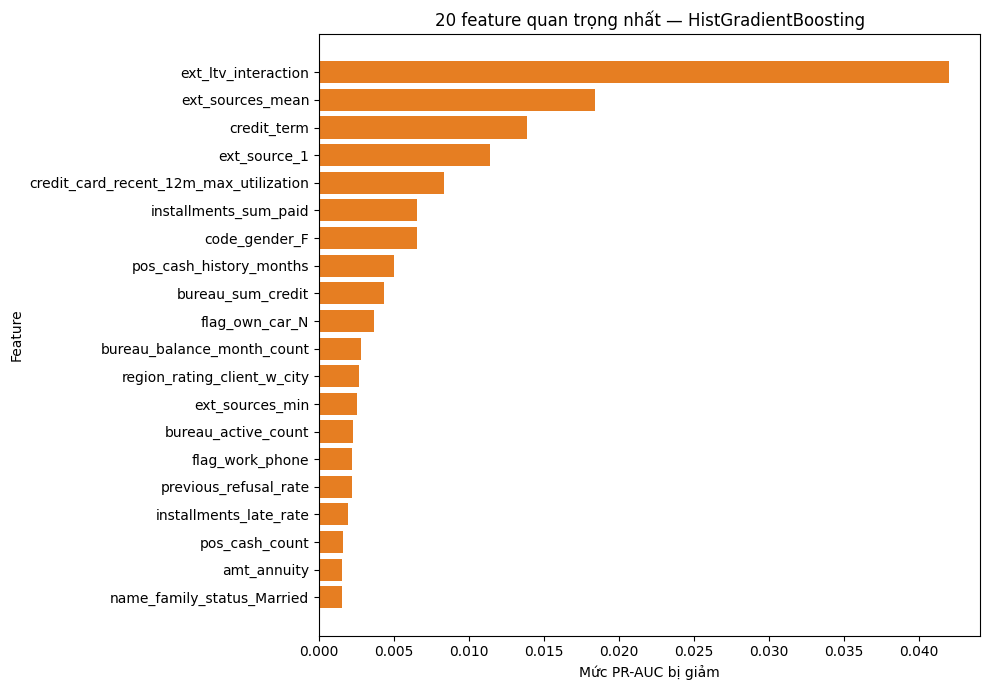

In [49]:
# Hiển thị biểu đồ ngay trong notebook.
get_ipython().run_line_magic("matplotlib", "inline")

plt.figure(figsize=(10, 7))
plt.barh(top_20_hgb.index[::-1], top_20_hgb.values[::-1], color="#E67E22")
plt.xlabel("Mức PR-AUC bị giảm")
plt.ylabel("Feature")
plt.title("20 feature quan trọng nhất — HistGradientBoosting")
plt.tight_layout()
plt.show()

### 7. Lưu mô hình HistGradientBoosting

Đoạn code bên dưới lưu HistGradientBoosting và các metric để sử dụng ở phần so sánh, lựa chọn mô hình.

In [50]:
# Lưu thông tin và metric của mô hình ứng viên.
metrics_hgb = {
    "model_name": "Credit Risk Classification - HistGradientBoosting",
    "model_type": type(hgb_model).__name__,
    "model_version": "1.0.0",
    "status": "Candidate",
    "dataset": "application_features",
    "target": TARGET_COLUMN,
    "trained_date": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "trained_from": "06_modeling_evaluation.ipynb",
    "train_rows": len(X_train_hgb),
    "test_rows": len(X_test_hgb),
    "train_test_split": "80/20 Stratified",
    "features_count": len(FEATURE_NAMES),
    "decision_threshold": NGUONG_TAM_THOI_HGB,
    "accuracy": round(float((y_test_pred_hgb == y_test.to_numpy()).mean()), 4),
    "roc_auc": round(float(chi_so_hgb_test["ROC-AUC"]), 4),
    "pr_auc": round(float(chi_so_hgb_test["PR-AUC"]), 4),
    "precision_class_1": round(float(chi_so_hgb_test["Precision"]), 4),
    "recall_class_1": round(float(chi_so_hgb_test["Recall"]), 4),
    "f1_class_1": round(float(chi_so_hgb_test["F1-Score"]), 4),
    "confusion_matrix": ma_tran_hgb.tolist(),
    "author": "Nhóm 01",
}

# Gói mô hình kèm các thông tin cần dùng lại.
goi_hist_gradient_boosting = {
    "model": hgb_model,
    "feature_names": FEATURE_NAMES,
    "can_chuan_hoa": False,
    "nguong_tam_thoi": NGUONG_TAM_THOI_HGB,
    "metrics_test": metrics_hgb,
}

duong_dan_hgb = MODELS_DIR / "hist_gradient_boosting.pkl"
duong_dan_metrics_hgb = MODELS_DIR / "hist_gradient_boosting_metrics.json"

# Ghi mô hình và metric xuống thư mục models.
joblib.dump(goi_hist_gradient_boosting, duong_dan_hgb)
duong_dan_metrics_hgb.write_text(
    json.dumps(metrics_hgb, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"Đã lưu mô hình: {duong_dan_hgb}")
print(f"Đã lưu metric: {duong_dan_metrics_hgb}")

Đã lưu mô hình: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\hist_gradient_boosting.pkl
Đã lưu metric: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\hist_gradient_boosting_metrics.json


## VII. So sánh các mô hình

### 1. Bảng tổng hợp kết quả

Đoạn code bên dưới tổng hợp kết quả của ba mô hình trên cùng tập Test và cùng ngưỡng tạm thời 0,5.

In [51]:
# Gom kết quả của ba mô hình vào cùng một bảng.
bang_so_sanh_mo_hinh = pd.DataFrame({
    "Mô hình": [
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting",
    ],
    "Thời gian (giây)": [
        thoi_gian_lr,
        thoi_gian_rf,
        thoi_gian_hgb,
    ],
    "ROC-AUC": [
        chi_so_lr_test["ROC-AUC"],
        chi_so_rf_test["ROC-AUC"],
        chi_so_hgb_test["ROC-AUC"],
    ],
    "PR-AUC": [
        chi_so_lr_test["PR-AUC"],
        chi_so_rf_test["PR-AUC"],
        chi_so_hgb_test["PR-AUC"],
    ],
    "Precision": [
        chi_so_lr_test["Precision"],
        chi_so_rf_test["Precision"],
        chi_so_hgb_test["Precision"],
    ],
    "Recall": [
        chi_so_lr_test["Recall"],
        chi_so_rf_test["Recall"],
        chi_so_hgb_test["Recall"],
    ],
    "F1-score": [
        chi_so_lr_test["F1-Score"],
        chi_so_rf_test["F1-Score"],
        chi_so_hgb_test["F1-Score"],
    ],
})

# Làm tròn để bảng dễ đọc.
bang_so_sanh_mo_hinh["Thời gian (giây)"] = bang_so_sanh_mo_hinh["Thời gian (giây)"].round(1)
cac_cot_metric = ["ROC-AUC", "PR-AUC", "Precision", "Recall", "F1-score"]
bang_so_sanh_mo_hinh[cac_cot_metric] = bang_so_sanh_mo_hinh[cac_cot_metric].round(4)

display(bang_so_sanh_mo_hinh)

,Mô hình,Thời gian (giây),ROC-AUC,PR-AUC,Precision,Recall,F1-score
0,Logistic Regression,30.6,0.7714,0.2544,0.1741,0.6994,0.2788
1,Random Forest,79.5,0.7600,0.2424,0.1890,0.6163,0.2893
2,HistGradientBoosting,24.1,0.7780,0.2717,0.1840,0.6871,0.2903


**Nhận xét:**

- HistGradientBoosting đứng đầu về ROC-AUC (`0,7780`), PR-AUC (`0,2717`) và F1-score (`0,2903`), đồng thời có thời gian huấn luyện thấp nhất trong lần chạy này.
- Random Forest có Precision cao nhất (`0,1890`) nhưng Recall và PR-AUC thấp hơn. Logistic Regression có Recall cao nhất (`0,6994`) nhưng tạo nhiều cảnh báo nhầm.
- Xét khả năng xếp hạng rủi ro và sự cân bằng giữa Precision–Recall, nhóm chọn HistGradientBoosting làm mô hình ứng viên cho bước tối ưu ngưỡng và NB07.


## VIII. Tổng kết

- Ba mô hình được huấn luyện và đánh giá trên cùng tập Test, cùng ngưỡng tạm thời `0,5`.
- HistGradientBoosting là mô hình tốt nhất theo ROC-AUC, PR-AUC và F1-score.
- Ba vòng đào feature cho thấy `credit_card_recent_12m_max_utilization` là bổ sung có giá trị nhất; bốn interaction vòng 3 chưa cải thiện kết quả tổng thể.
- Bước tiếp theo là lựa chọn ngưỡng dự đoán trên tập Validation, sau đó lưu mô hình và ngưỡng cuối để sử dụng trong NB07.
